<a href="https://colab.research.google.com/github/SalmanRadhitya/Tugas-Machine-Learning-Clustering/blob/main/Tugas_ML_Clustering_014.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**IMPORTING LIBRARIES**

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

Penjelasan:
Mengimpor pustaka yang dibutuhkan:

`pandas` dan `numpy`: untuk manipulasi data.

`matplotlib.pyplot` dan `seaborn`: untuk visualisasi.

`StandardScaler`, `KMeans`, dan `PCA`: bagian dari scikit-learn untuk preprocessing, model, dan reduksi dimensi.

#**LOAD DATASET**

In [27]:
df = pd.read_csv("/content/customer_segmentation_data.csv")
print(df.head())

   id  age  gender  income  spending_score  membership_years  \
0   1   38  Female   99342              90                 3   
1   2   21  Female   78852              60                 2   
2   3   60  Female  126573              30                 2   
3   4   40   Other   47099              74                 9   
4   5   65  Female  140621              21                 3   

   purchase_frequency preferred_category  last_purchase_amount  
0                  24          Groceries                113.53  
1                  42             Sports                 41.93  
2                  28           Clothing                424.36  
3                   5      Home & Garden                991.93  
4                  25        Electronics                347.08  


In [16]:
df.describe()

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


In [17]:
df.shape

(1000, 9)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


In [19]:
df.isnull().sum()

,0
id,0
age,0
gender,0
income,0
spending_score,0
membership_years,0
purchase_frequency,0
preferred_category,0
last_purchase_amount,0


karena tidak ada missing value atau data yang hilang maka langsu lanjut saja ke proses preprosessing

#**DATA PREPROCESSING**

In [28]:
#Drop kolom ID
df = df.drop(columns=["id"])

Kolom ID tidak berkontribusi pada pola segmentasi, jadi dihapus.

In [29]:
#Encode Variabel Kategorikal
df_encoded = pd.get_dummies(df, columns=["gender", "preferred_category"])

Variabel kategorikal diubah menjadi format numerik dengan one-hot encoding agar bisa digunakan di K-Means.

In [30]:
#Scaling Fitur Numerik
numerical_cols = ['age', 'income', 'spending_score', 'membership_years',
                  'purchase_frequency', 'last_purchase_amount']

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

K-Means sensitif terhadap skala fitur, jadi fitur numerik dinormalisasi agar memiliki skala yang sama.

#**MENENTUKAN JUMLAH CLUSTER**

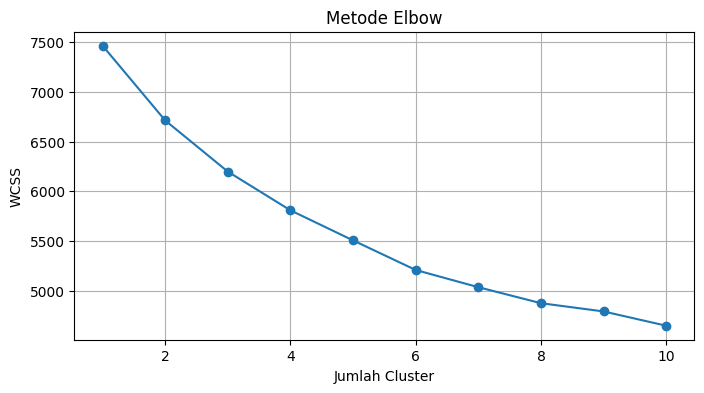

In [32]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_encoded)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Metode Elbow')
plt.xlabel('Jumlah Cluster')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Digunakan untuk memilih jumlah cluster terbaik dengan melihat titik “siku” di grafik.

#**Evaluasi K Alternatif dengan Silhouette Score**

In [33]:
print("\nSilhouette Scores untuk masing-masing K:")
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_encoded)
    score = silhouette_score(df_encoded, labels)
    print(f"K = {k} --> Silhouette Score = {score:.3f}")


Silhouette Scores untuk masing-masing K:
K = 2 --> Silhouette Score = 0.097
K = 3 --> Silhouette Score = 0.091
K = 4 --> Silhouette Score = 0.092
K = 5 --> Silhouette Score = 0.094
K = 6 --> Silhouette Score = 0.100
K = 7 --> Silhouette Score = 0.097
K = 8 --> Silhouette Score = 0.094
K = 9 --> Silhouette Score = 0.088
K = 10 --> Silhouette Score = 0.088


Melihat skor kualitas clustering untuk berbagai nilai K.

#**Training Model KMeans (Dengan K Terbaik)**

In [34]:
k = 4  # Ganti nilai ini sesuai hasil analisis Elbow atau Silhouette
kmeans = KMeans(n_clusters=k, random_state=42)
df_encoded['cluster'] = kmeans.fit_predict(df_encoded)

# Hitung silhouette score akhir
final_score = silhouette_score(df_encoded.drop(columns=["cluster"]), df_encoded["cluster"])
print(f"\nSilhouette Score Final (K={k}): {final_score:.3f}")


Silhouette Score Final (K=4): 0.092


Melatih model KMeans dan menghitung Silhouette Score akhir.

#**Visualisasi Cluster (PCA 2D)**

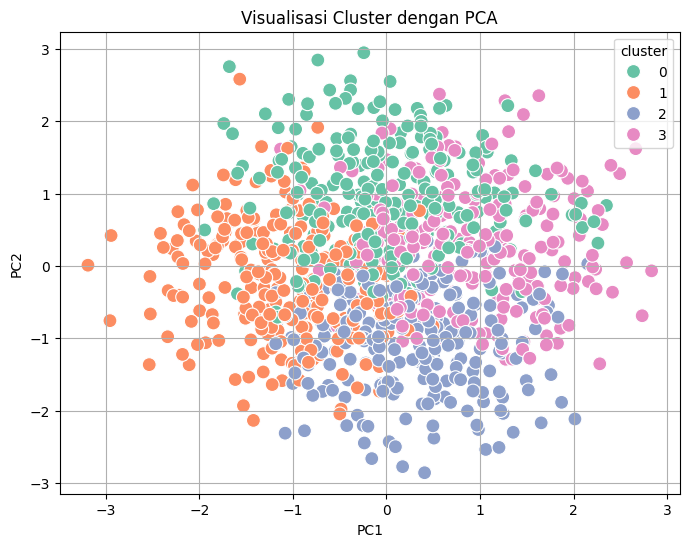

In [35]:
pca = PCA(n_components=2)
components = pca.fit_transform(df_encoded.drop(columns=["cluster"]))

df_viz = pd.DataFrame(components, columns=["PC1", "PC2"])
df_viz["cluster"] = df_encoded["cluster"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_viz, x="PC1", y="PC2", hue="cluster", palette="Set2", s=100)
plt.title("Visualisasi Cluster dengan PCA")
plt.grid(True)
plt.show()

#**Analisis Setiap Cluster**

In [36]:
df_original = pd.read_csv("customer_segmentation_data.csv")
df_original['cluster'] = df_encoded['cluster']

cluster_summary = df_original.groupby('cluster').mean(numeric_only=True)
print("\nRata-rata fitur numerik per cluster:")
print(cluster_summary)


Rata-rata fitur numerik per cluster:
                 id        age        income  spending_score  \
cluster                                                        
0        514.388000  47.596000  82713.164000       28.996000   
1        491.256506  45.319703  98554.609665       56.319703   
2        497.599174  35.454545  92350.235537       38.367769   
3        499.313808  46.497908  79341.263598       79.502092   

         membership_years  purchase_frequency  last_purchase_amount  
cluster                                                              
0                4.752000           24.576000            769.560960  
1                4.330855           14.174721            273.602007  
2                6.148760           38.115702            291.188223  
3                6.811715           31.025105            652.267531  


#**Simpan Data K-Means Clustering**

In [39]:
df_encoded.to_csv("customer_segmentation_data_clustered.csv", index=False)